# Przygotowanie danych dla zbiorów Mushroom i Adult Income

**Autorzy opracowania:**
- Kateryna Kolioglo 113577
- Kacper Kukuła 113132
- Kacper Zamiatała 113667
- Szczepan Kurtek 113323
- Mateusz Krówczyński 89531

**Charakter dokumentu:** notebook wprowadzający do części modelowej projektu.

### Zakres notebooka:
1. [Import bibliotek](#0)
2. [Wprowadzenie do datasetów](#1)
3. [Analiza datasetu Mushroom](#3)
4. [Analiza datasetu Adult Income](#4)
5. [Porównanie obu datasetów](#5)



## Powiązane notebooki

Ten notebook stanowi część wprowadzającą do dalszej analizy modelowej.
Kolejne etapy projektu zostały opisane w osobnych notebookach:
- `01_logistic_regression.ipynb`
- `02_decision_tree.ipynb`
- `03_random_forest.ipynb`
- `04_knn.ipynb`
- `05_bernoulli_naive_bayes.ipynb`

Przyjęta struktura pozwala oddzielić przygotowanie danych od analizy
konkretnych algorytmów klasyfikacyjnych.


### <a name='0'></a> Import bibliotek

W tym notebooku pokazujemy oba wykorzystywane datasety:
- `mushroom` jako dataset główny,
- `adult_income` jako zewnętrzny dataset porównawczy.

Celem jest pokazanie, jak wyglądają dane jeszcze przed przejściem
do osobnych analiz modeli.


In [1]:
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

from mushroom_analysis import (
    TARGET_COLUMN,
    BernoulliNB,
    DecisionTreeClassifier,
    KNeighborsClassifier,
    LogisticRegression,
    RANDOM_STATE,
    RandomForestClassifier,
    class_balance_table,
    evaluate_models,
    load_data,
    load_dataset,
    missing_values_table,
    oversample_minority_class,
    plot_class_distribution,
    plot_confusion_matrix_for_model,
    plot_feature_histograms,
    plot_model_comparison,
    plot_top_feature_correlations,
    preprocess_after_split,
    split_dataset,
)


### <a name='1'></a> Wprowadzenie do datasetów

W projekcie wykorzystujemy dwa zbiory danych:

1. `mushroom`
- klasyfikacja grzybów na `edible` i `poisonous`,
- przewaga cech kategorycznych,
- dataset bardzo dobrze separowalny.

2. `adult_income`
- klasyfikacja dochodu `<=50K` oraz `>50K`,
- cechy mieszane: numeryczne i kategoryczne,
- problem trudniejszy i bardziej realistyczny.


### <a name='3'></a> Analiza datasetu Mushroom

Najpierw analizujemy główny dataset projektu, czyli `mushroom`.


In [2]:
df = load_dataset("mushroom")
df.head()


,class,cap_shape,cap_surface,cap_color,bruises,odor,gill_attachment,gill_spacing,gill_size,gill_color,...,stalk_surface_below_ring,stalk_color_above_ring,stalk_color_below_ring,veil_type,veil_color,ring_number,ring_type,spore_print_color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [3]:
df.shape


(8124, 23)

In [4]:
mushroom_balance = class_balance_table(df[TARGET_COLUMN])
mushroom_balance


,class_code,class_name,count,percentage
0,e,edible,4208,51.8
1,p,poisonous,3916,48.2


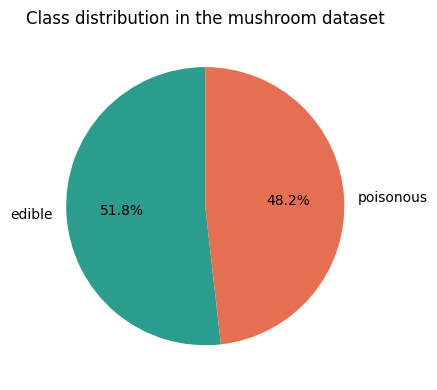

In [5]:
plot_class_distribution(df[TARGET_COLUMN], dataset_name="mushroom")


In [6]:
balance_df = class_balance_table(df[TARGET_COLUMN])
edible_row = balance_df[balance_df["class_code"] == "e"].iloc[0]
poisonous_row = balance_df[balance_df["class_code"] == "p"].iloc[0]

print(
    f"Wnioski: w zbiorze znajduje sie {int(edible_row['count'])} grzybow jadalnych "
    f"({edible_row['percentage']:.1f}%) oraz {int(poisonous_row['count'])} grzybow trujacych "
    f"({poisonous_row['percentage']:.1f}%). Oznacza to, ze klasy sa prawie zbalansowane."
)


Wnioski: w zbiorze znajduje sie 4208 grzybow jadalnych (51.8%) oraz 3916 grzybow trujacych (48.2%). Oznacza to, ze klasy sa prawie zbalansowane.


In [7]:
train_df, validation_df, test_df = split_dataset(df)

pd.DataFrame(
    [
        {"split": "train", "rows": len(train_df)},
        {"split": "validation", "rows": len(validation_df)},
        {"split": "test", "rows": len(test_df)},
    ]
)


,split,rows
0,train,5686
1,validation,1219
2,test,1219


In [8]:
missing_values_table(
    ("train", train_df),
    ("validation", validation_df),
    ("test", test_df),
)


,split,column,missing_count
0,train,stalk_root,1740
1,validation,stalk_root,363
2,test,stalk_root,377


In [9]:
missing_df = missing_values_table(
    ("train", train_df),
    ("validation", validation_df),
    ("test", test_df),
)

total_missing = int(missing_df["missing_count"].sum())
train_missing = int(missing_df.loc[missing_df["split"] == "train", "missing_count"].sum())
validation_missing = int(missing_df.loc[missing_df["split"] == "validation", "missing_count"].sum())
test_missing = int(missing_df.loc[missing_df["split"] == "test", "missing_count"].sum())

print(
    f"Wnioski: wykryto lacznie {total_missing} brakujacych wartosci, "
    f"w tym {train_missing} w zbiorze treningowym, {validation_missing} w walidacyjnym "
    f"oraz {test_missing} w testowym. Braki wystepuja w kolumnie 'stalk_root', "
    f"dlatego imputacja po podziale danych jest konieczna."
)


Wnioski: wykryto lacznie 2480 brakujacych wartosci, w tym 1740 w zbiorze treningowym, 363 w walidacyjnym oraz 377 w testowym. Braki wystepuja w kolumnie 'stalk_root', dlatego imputacja po podziale danych jest konieczna.


In [10]:
preprocessed = preprocess_after_split(train_df, validation_df, test_df)

print("X_train_model:", preprocessed["X_train_model"].shape)
print("X_validation_model:", preprocessed["X_validation_model"].shape)
print("X_test_model:", preprocessed["X_test_model"].shape)


X_train_model: (5686, 116)
X_validation_model: (1219, 116)
X_test_model: (1219, 116)


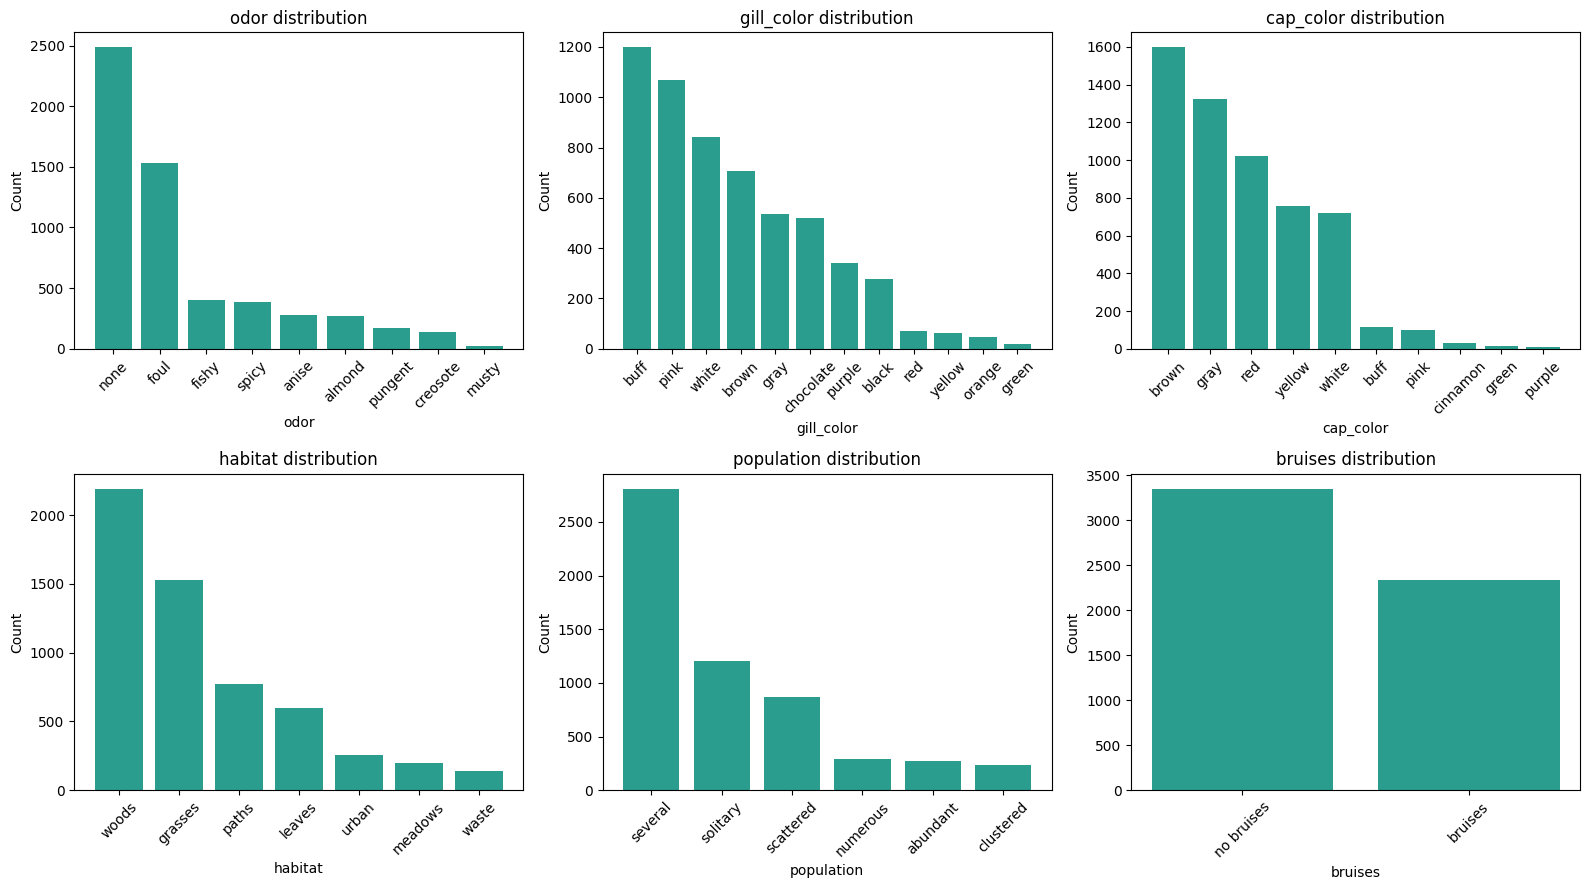

In [11]:
plot_feature_histograms(train_df, dataset_name="mushroom")


c:\Users\imper\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\imper\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


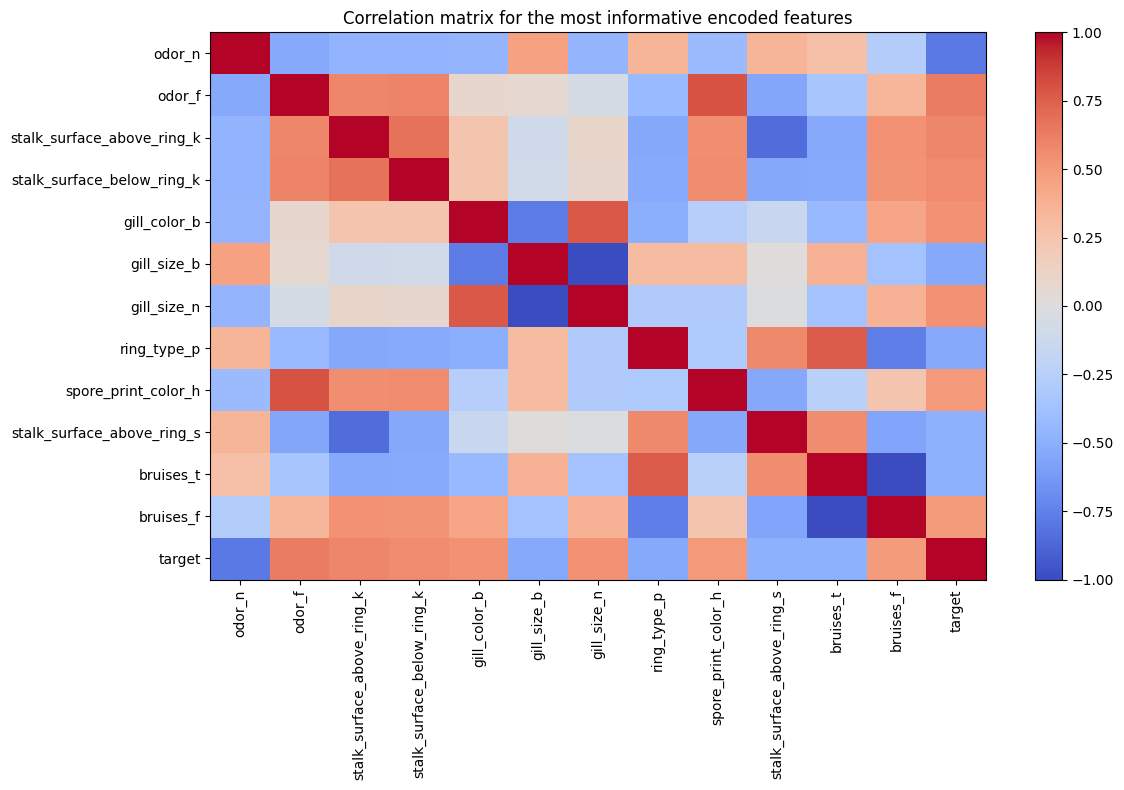

,encoded_feature,absolute_target_correlation,feature_description
0,odor_n,0.787583,odor = none
1,odor_f,0.628640,odor = foul
2,stalk_surface_above_ring_k,0.587159,stalk_surface_above_ring = silky
3,stalk_surface_below_ring_k,0.569723,stalk_surface_below_ring = silky
4,gill_color_b,0.535538,gill_color = buff
5,gill_size_b,0.533433,gill_size = broad
6,gill_size_n,0.533433,gill_size = narrow
7,ring_type_p,0.531636,ring_type = pendant
8,spore_print_color_h,0.494189,spore_print_color = chocolate
9,stalk_surface_above_ring_s,0.491034,stalk_surface_above_ring = smooth


In [12]:
top_correlations = plot_top_feature_correlations(
    preprocessed["X_train_encoded"],
    preprocessed["y_train"],
    top_n=12,
    feature_columns=preprocessed["feature_columns"],
)
top_correlations


In [13]:
strongest = top_correlations.iloc[0]
print(
    f"Wnioski: najsilniej z targetem powiazana jest cecha "
    f"'{strongest['encoded_feature']}' o bezwzglednej korelacji "
    f"{strongest['absolute_target_correlation']:.4f}. Potwierdza to, ze czesc cech "
    f"bardzo dobrze rozroznia klasy jadalne i trujace."
)


Wnioski: najsilniej z targetem powiazana jest cecha 'odor_n' o bezwzglednej korelacji 0.7876. Potwierdza to, ze czesc cech bardzo dobrze rozroznia klasy jadalne i trujace.


### Wyniki wszystkich modeli dla Mushroom

Na tym etapie zestawiamy pięć analizowanych algorytmów,
aby sprawdzić, który model najlepiej radzi sobie na głównym datasecie projektu.


In [14]:
results_df = evaluate_models(preprocessed).drop(columns="fitted_model")
results_df


,model,balancing_strategy,validation_accuracy,validation_precision,validation_recall,validation_f1,test_accuracy,test_precision,test_recall,test_f1
0,Decision Tree,class_weight,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
1,Random Forest,class_weight,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
2,Logistic Regression,class_weight,0.9992,1.0000,0.9983,0.9991,0.9992,1.0000,0.9983,0.9991
3,KNN,oversample,0.9975,1.0000,0.9949,0.9974,0.9992,1.0000,0.9983,0.9991
4,Bernoulli Naive Bayes,oversample,0.9377,0.9867,0.8827,0.9318,0.9418,0.9813,0.8961,0.9368


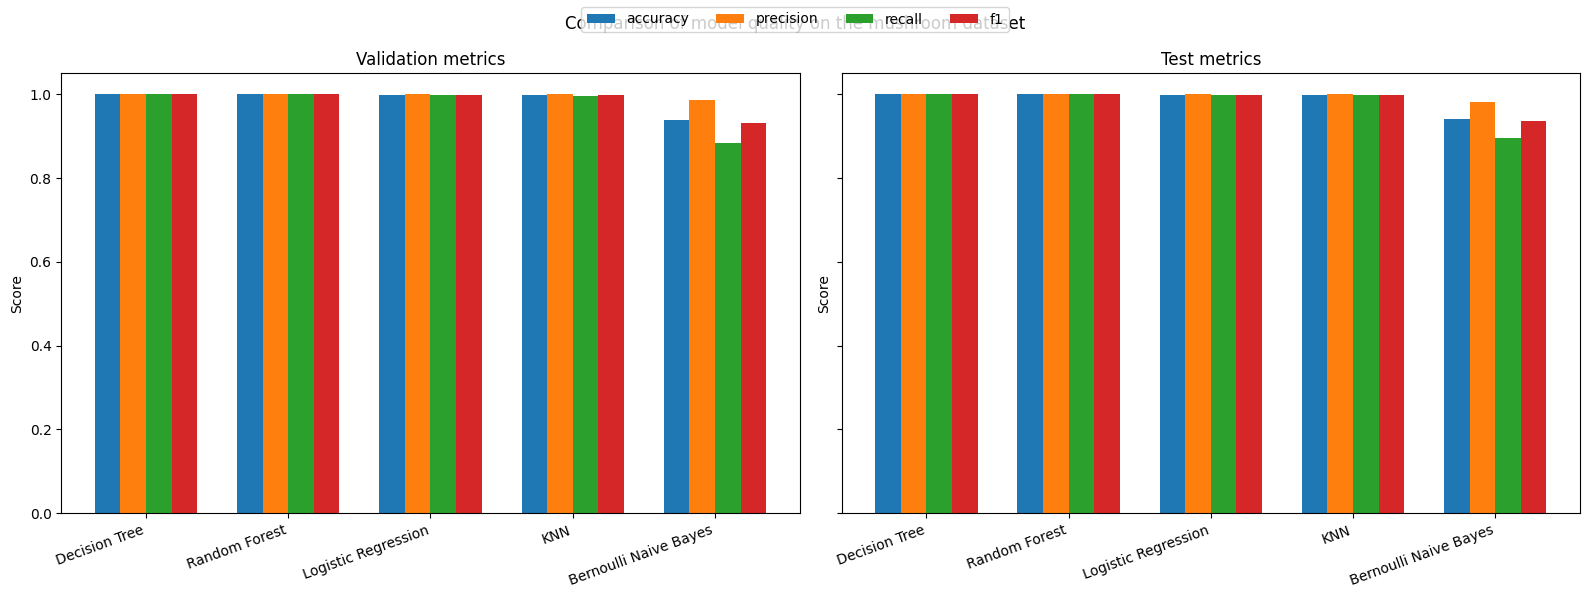

In [15]:
plot_model_comparison(results_df, dataset_name="mushroom")


In [16]:
best_row = results_df.iloc[0]
print(
    f"Wnioski ogolne: najlepszy wynik walidacyjny uzyskal model "
    f"{best_row['model']} z accuracy = {best_row['validation_accuracy']:.4f} "
    f"oraz F1 = {best_row['validation_f1']:.4f}. Oznacza to, ze problem klasyfikacji "
    f"na zbiorze mushroom jest bardzo dobrze separowalny."
)


Wnioski ogolne: najlepszy wynik walidacyjny uzyskal model Decision Tree z accuracy = 1.0000 oraz F1 = 1.0000. Oznacza to, ze problem klasyfikacji na zbiorze mushroom jest bardzo dobrze separowalny.


### <a name='4'></a> Analiza datasetu Adult Income

Teraz pokazujemy podstawową charakterystykę drugiego datasetu,
który służy jako trudniejszy punkt odniesienia dla tych samych algorytmów.


In [17]:
adult_df = load_dataset("adult_income")
adult_df.head()


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,class
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [18]:
adult_df.shape


(32561, 15)

In [19]:
adult_balance = class_balance_table(adult_df[TARGET_COLUMN])
adult_balance


,class_code,class_name,count,percentage
0,<=50K,<=50K,24720,75.92
1,>50K,>50K,7841,24.08


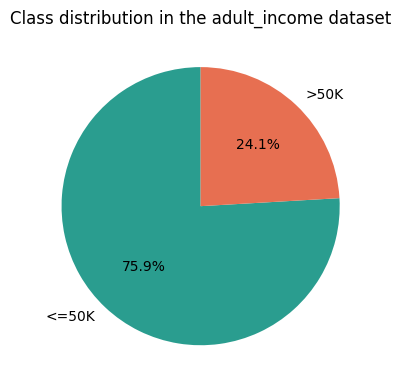

In [20]:
plot_class_distribution(adult_df[TARGET_COLUMN], dataset_name="adult_income")


In [21]:
adult_train_df, adult_validation_df, adult_test_df = split_dataset(adult_df)

pd.DataFrame(
    [
        {"split": "train", "rows": len(adult_train_df)},
        {"split": "validation", "rows": len(adult_validation_df)},
        {"split": "test", "rows": len(adult_test_df)},
    ]
)


,split,rows
0,train,22792
1,validation,4884
2,test,4885


In [22]:
missing_values_table(
    ("train", adult_train_df),
    ("validation", adult_validation_df),
    ("test", adult_test_df),
)


,split,column,missing_count
0,train,workclass,1275
1,train,occupation,1281
2,train,native_country,407
3,validation,workclass,268
4,validation,occupation,269
5,validation,native_country,86
6,test,workclass,293
7,test,occupation,293
8,test,native_country,90


In [23]:
adult_preprocessed = preprocess_after_split(adult_train_df, adult_validation_df, adult_test_df)

print("X_train_model:", adult_preprocessed["X_train_model"].shape)
print("X_validation_model:", adult_preprocessed["X_validation_model"].shape)
print("X_test_model:", adult_preprocessed["X_test_model"].shape)


X_train_model: (22792, 105)
X_validation_model: (4884, 105)
X_test_model: (4885, 105)


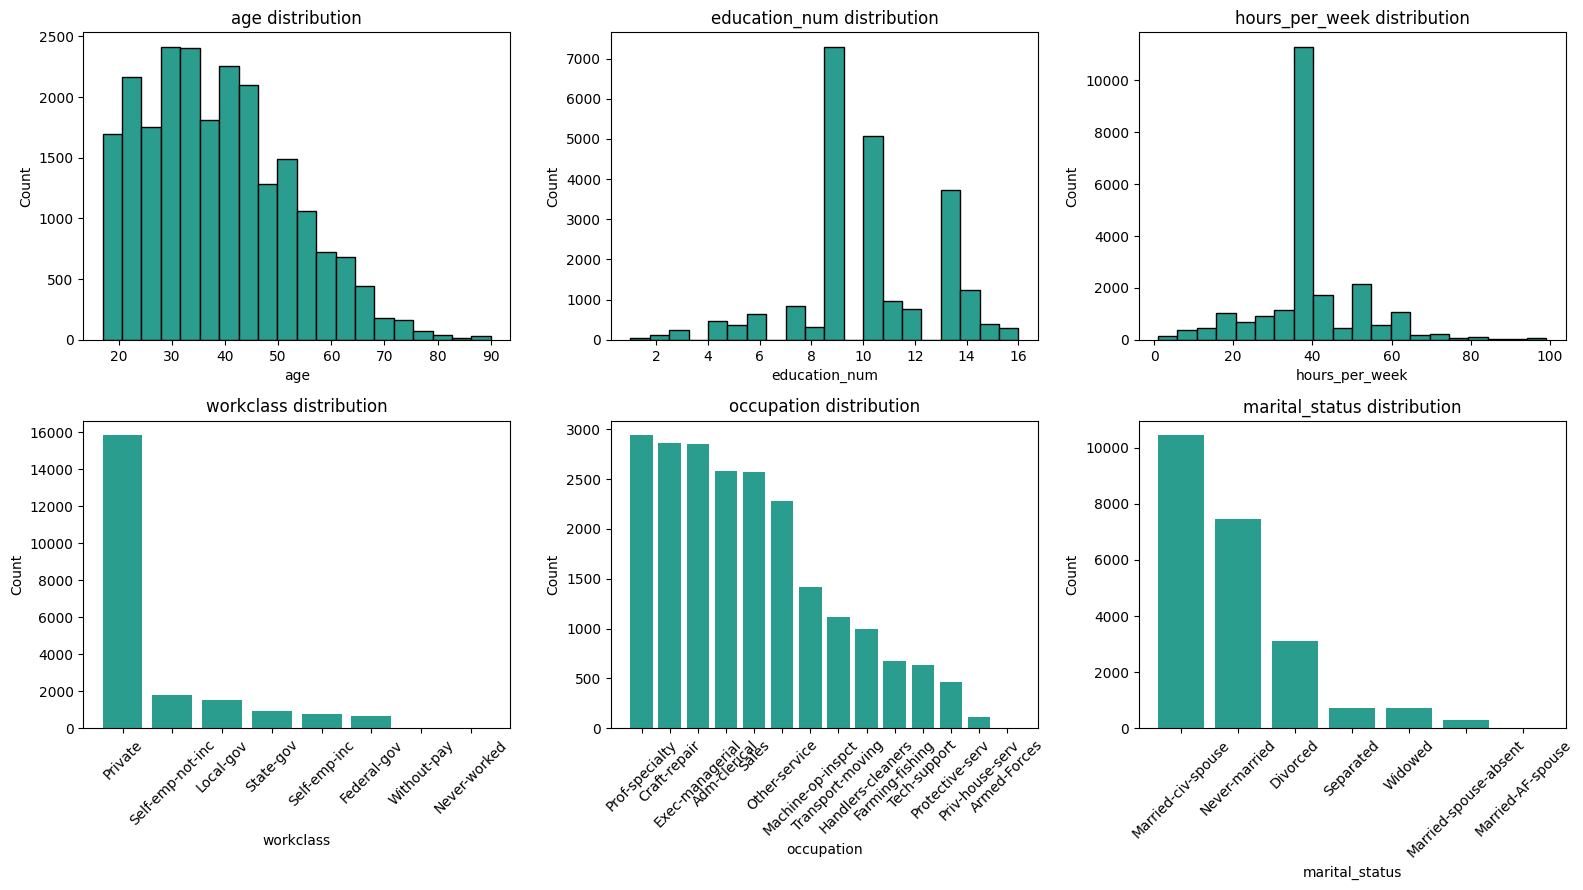

In [24]:
plot_feature_histograms(adult_train_df, dataset_name="adult_income")


### Wyniki wszystkich modeli dla Adult Income

Tak jak dla `mushroom`, chcemy sprawdzic rowniez,
jak wszystkie analizowane algorytmy radza sobie
na bardziej wymagajacym datasecie `adult_income`.


In [25]:
adult_results_df = evaluate_models(adult_preprocessed).drop(columns="fitted_model")
adult_results_df


,model,balancing_strategy,validation_accuracy,validation_precision,validation_recall,validation_f1,test_accuracy,test_precision,test_recall,test_f1
0,Random Forest,class_weight,0.8342,0.6144,0.8359,0.7082,0.8395,0.6255,0.8308,0.7137
1,Logistic Regression,class_weight,0.8120,0.5726,0.8656,0.6892,0.8039,0.5610,0.8520,0.6766
2,Decision Tree,class_weight,0.8075,0.5666,0.8537,0.6811,0.7992,0.5542,0.8478,0.6703
3,KNN,oversample,0.7887,0.5389,0.8486,0.6592,0.7844,0.5334,0.8350,0.6510
4,Bernoulli Naive Bayes,oversample,0.7512,0.4904,0.8427,0.6200,0.7529,0.4924,0.8563,0.6253


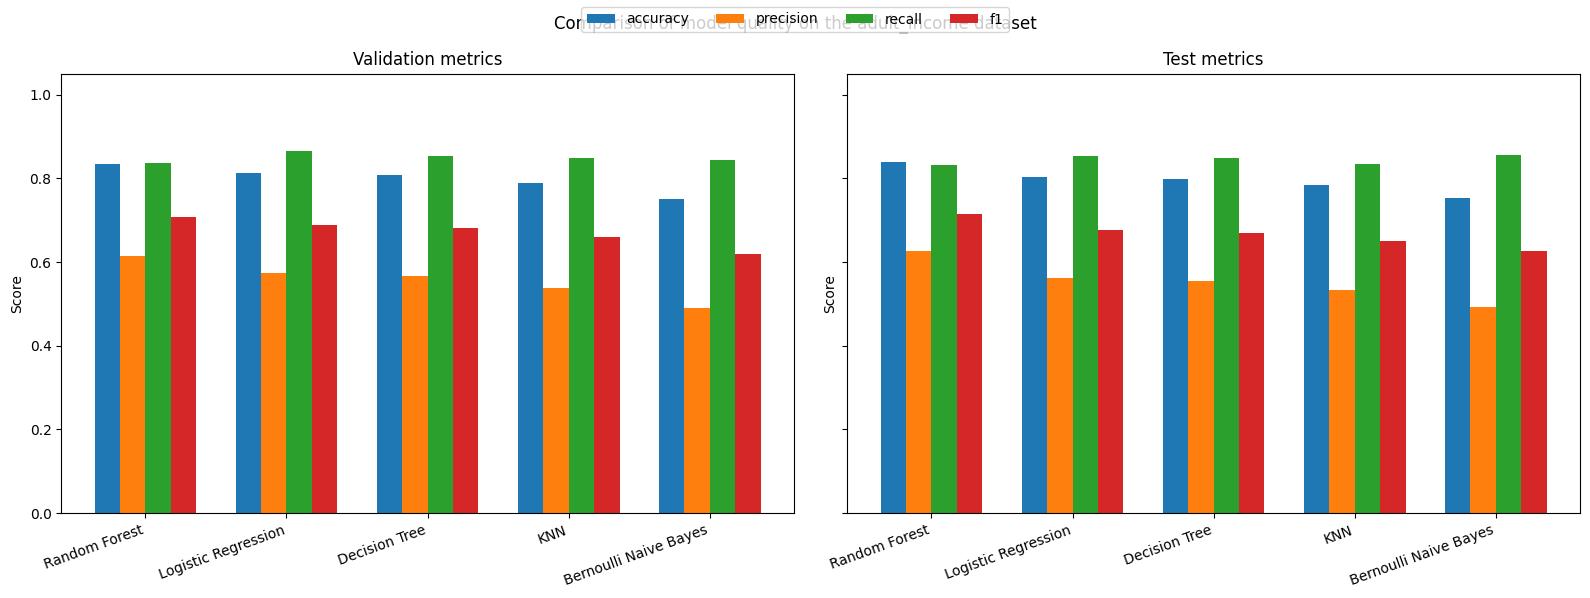

In [26]:
plot_model_comparison(adult_results_df, dataset_name="adult_income")


In [27]:
adult_best_row = adult_results_df.iloc[0]
print(
    f"Wnioski dla Adult Income: najlepszy wynik walidacyjny uzyskal model "
    f"{adult_best_row['model']} z accuracy = {adult_best_row['validation_accuracy']:.4f} "
    f"oraz F1 = {adult_best_row['validation_f1']:.4f}. Wyniki sa wyraznie nizsze "
    f"niz dla mushroom, co potwierdza wieksza trudnosc tego problemu."
)


Wnioski dla Adult Income: najlepszy wynik walidacyjny uzyskal model Random Forest z accuracy = 0.8342 oraz F1 = 0.7082. Wyniki sa wyraznie nizsze niz dla mushroom, co potwierdza wieksza trudnosc tego problemu.


**Wnioski po analizie Adult Income**

Dataset `adult_income` jest bardziej zlozony niz `mushroom`,
poniewaz laczy cechy liczbowe i kategoryczne. Dodatkowo problem
klasyfikacji dochodu jest mniej separowalny, co prowadzi
do bardziej realistycznych wynikow modeli.


### <a name='5'></a> Porównanie obu datasetów

Na końcu porównujemy podstawowe cechy obu zbiorów,
aby lepiej uzasadnić, dlaczego wyniki modeli różnią się
pomiedzy `mushroom` a `adult_income`.


In [28]:
mushroom_best_row = results_df.iloc[0]

pd.DataFrame(
    [
        {
            "dataset": "mushroom",
            "rows": len(df),
            "columns": df.shape[1],
            "target": "edible / poisonous",
            "best_model": mushroom_best_row["model"],
            "best_validation_f1": mushroom_best_row["validation_f1"],
        },
        {
            "dataset": "adult_income",
            "rows": len(adult_df),
            "columns": adult_df.shape[1],
            "target": "<=50K / >50K",
            "best_model": adult_best_row["model"],
            "best_validation_f1": adult_best_row["validation_f1"],
        },
    ]
)


,dataset,rows,columns,target,best_model,best_validation_f1
0,mushroom,8124,23,edible / poisonous,Decision Tree,1.0000
1,adult_income,32561,15,<=50K / >50K,Random Forest,0.7082


In [29]:
print(
    "Wnioski koncowe: mushroom jest datasetem bardziej regularnym i latwiejszym "
    "do klasyfikacji, natomiast adult_income jest zbiorem trudniejszym, bardziej "
    "zroznicowanym i blizszym rzeczywistym problemom klasyfikacyjnym. "
    "Dodatkowo porownanie najlepszych modeli pokazuje, ze nawet bardzo dobry "
    "algorytm na trudniejszym datasecie nie osiaga wynikow tak wysokich jak na mushroom."
)


Wnioski koncowe: mushroom jest datasetem bardziej regularnym i latwiejszym do klasyfikacji, natomiast adult_income jest zbiorem trudniejszym, bardziej zroznicowanym i blizszym rzeczywistym problemom klasyfikacyjnym. Dodatkowo porownanie najlepszych modeli pokazuje, ze nawet bardzo dobry algorytm na trudniejszym datasecie nie osiaga wynikow tak wysokich jak na mushroom.
